In [1]:
import tensorflow as tf

from tensorflow.keras import datasets, layers, models
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import MaxPooling2D, Conv2D

In [2]:
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 623s 4us/step


In [3]:
train_images.shape

(50000, 32, 32, 3)

In [4]:
train_images, test_images = train_images / 255.0, test_images / 255.0

In [5]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

In [6]:

train_images, test_images = train_images / 255.0, test_images / 255.0

In [7]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,320 (220.00 KB)

 Trainable params: 56,320 (220.00 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10))

In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
train_labels_categorical = to_categorical(train_labels)
test_labels_categorical = to_categorical(test_labels)

In [12]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [13]:
history = model.fit(
    train_images,
    train_labels_categorical,
    epochs=10,
    validation_split=0.1,
    batch_size=128
)


Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 62s 164ms/step - accuracy: 0.1908 - loss: 2.1689 - val_accuracy: 0.2620 - val_loss: 2.0321
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 79s 157ms/step - accuracy: 0.2814 - loss: 1.9840 - val_accuracy: 0.2952 - val_loss: 1.9268
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 55s 157ms/step - accuracy: 0.3262 - loss: 1.8741 - val_accuracy: 0.3330 - val_loss: 1.8274
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 53s 150ms/step - accuracy: 0.3549 - loss: 1.7936 - val_accuracy: 0.3572 - val_loss: 1.7654
Epoch 5/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 60s 170ms/step - accuracy: 0.3753 - loss: 1.7375 - val_accuracy: 0.3804 - val_loss: 1.7200
Epoch 6/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 60s 170ms/step - accuracy: 0.3929 - loss: 1.6917 - val_accuracy: 0.3930 - val_loss: 1.6692
Epoch 7/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 52s 147ms/step - accuracy: 0.4043 - loss: 1.6576 - val_accuracy: 0.4060 - val_loss: 1.6336
Epoch 8/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 53s 150ms/step - accuracy: 0.4153 - loss: 1

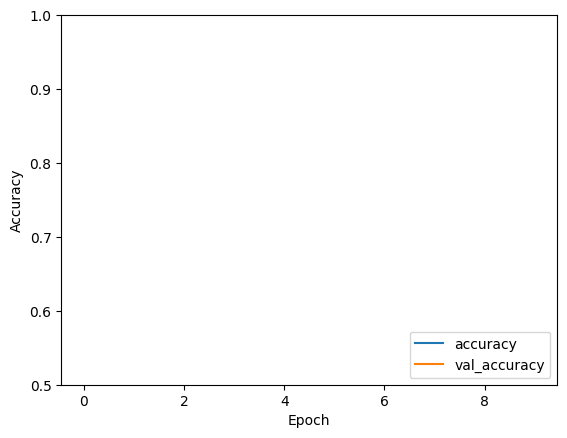

In [14]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

In [15]:
test_loss, test_acc = model.evaluate(
    test_images,
    test_labels_categorical,
    verbose=2
)

313/313 - 4s - 12ms/step - accuracy: 0.4501 - loss: 1.5480


In [16]:
print(test_acc)

0.45010000467300415


In [18]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

In [21]:
model_aug = tf.keras.Sequential([
    data_augmentation,
    tf.keras.layers.Rescaling(1./255),
    tf.keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10)
])

In [22]:
model_aug.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [23]:
model_aug.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [26]:
model_aug.compile(
    optimizer='adam',
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [27]:
epochs = 15

history_aug = model_aug.fit(
    train_images,
    train_labels_categorical,
    validation_split=0.1,
    epochs=epochs,
    batch_size=128
)

Epoch 1/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 116s 322ms/step - accuracy: 0.0997 - loss: 2.3027 - val_accuracy: 0.0970 - val_loss: 2.3027
Epoch 2/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 113s 320ms/step - accuracy: 0.0965 - loss: 2.3027 - val_accuracy: 0.0950 - val_loss: 2.3029
Epoch 3/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 112s 317ms/step - accuracy: 0.0990 - loss: 2.3027 - val_accuracy: 0.0958 - val_loss: 2.3027
Epoch 4/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 141s 315ms/step - accuracy: 0.0963 - loss: 2.3027 - val_accuracy: 0.0958 - val_loss: 2.3027
Epoch 5/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 143s 317ms/step - accuracy: 0.0982 - loss: 2.3027 - val_accuracy: 0.0950 - val_loss: 2.3028
Epoch 6/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 111s 315ms/step - accuracy: 0.0991 - loss: 2.3027 - val_accuracy: 0.0950 - val_loss: 2.3028
Epoch 7/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 144s 321ms/step - accuracy: 0.0984 - loss: 2.3027 - val_accuracy: 0.0958 - val_loss: 2.3028
Epoch 8/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 111s 315ms/step - accuracy: 0.0972 -

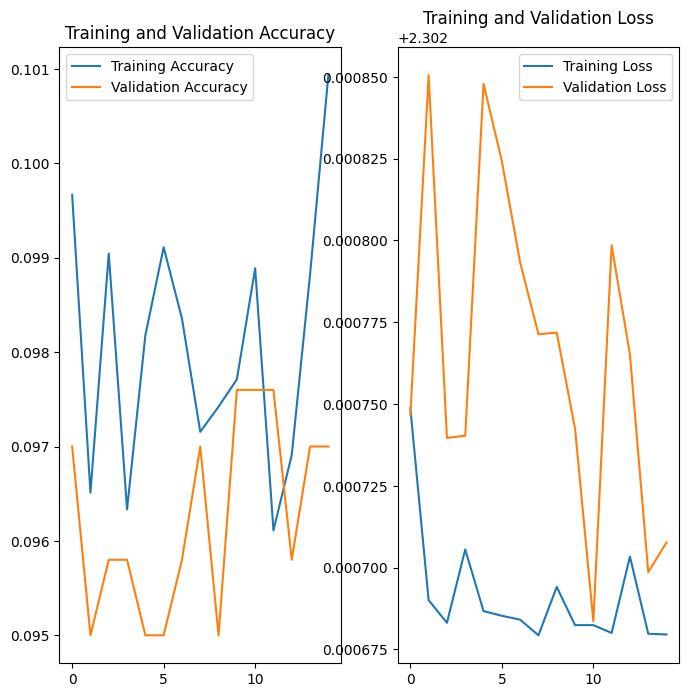

In [28]:
acc = history_aug.history['accuracy']
val_acc = history_aug.history['val_accuracy']

loss = history_aug.history['loss']
val_loss = history_aug.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Training and Validation Loss')

plt.show()

In [29]:
test_loss_aug, test_acc_aug = model_aug.evaluate(
    test_images,
    test_labels_categorical,
    verbose=2
)

print(test_acc_aug)

313/313 - 6s - 20ms/step - accuracy: 0.1000 - loss: 2.3026
0.10000000149011612


In [30]:
train_images = train_images * 255.0
test_images = test_images * 255.0

In [31]:
model_aug = tf.keras.Sequential([
    data_augmentation,
    tf.keras.layers.Rescaling(1./255),
    tf.keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10)
])

In [32]:
model_aug.compile(
    optimizer='adam',
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [33]:
epochs = 15

history_aug = model_aug.fit(
    train_images,
    train_labels_categorical,
    validation_split=0.1,
    epochs=epochs,
    batch_size=128
)


Epoch 1/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 115s 315ms/step - accuracy: 0.1508 - loss: 2.2288 - val_accuracy: 0.2522 - val_loss: 2.0466
Epoch 2/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 110s 314ms/step - accuracy: 0.2808 - loss: 1.9944 - val_accuracy: 0.3182 - val_loss: 1.9032
Epoch 3/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 139s 306ms/step - accuracy: 0.3236 - loss: 1.8785 - val_accuracy: 0.3570 - val_loss: 1.7968
Epoch 4/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 152s 334ms/step - accuracy: 0.3453 - loss: 1.8177 - val_accuracy: 0.3674 - val_loss: 1.7578
Epoch 5/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 143s 336ms/step - accuracy: 0.3643 - loss: 1.7661 - val_accuracy: 0.3812 - val_loss: 1.6919
Epoch 6/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 131s 306ms/step - accuracy: 0.3771 - loss: 1.7324 - val_accuracy: 0.4040 - val_loss: 1.6397
Epoch 7/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 112s 319ms/step - accuracy: 0.3934 - loss: 1.6903 - val_accuracy: 0.4214 - val_loss: 1.6019
Epoch 8/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 150s 342ms/step - accuracy: 0.4046 -

In [34]:
test_loss_aug, test_acc_aug = model_aug.evaluate(
    test_images,
    test_labels_categorical,
    verbose=2
)

print(test_acc_aug)

313/313 - 11s - 37ms/step - accuracy: 0.4800 - loss: 1.4547
0.47999998927116394


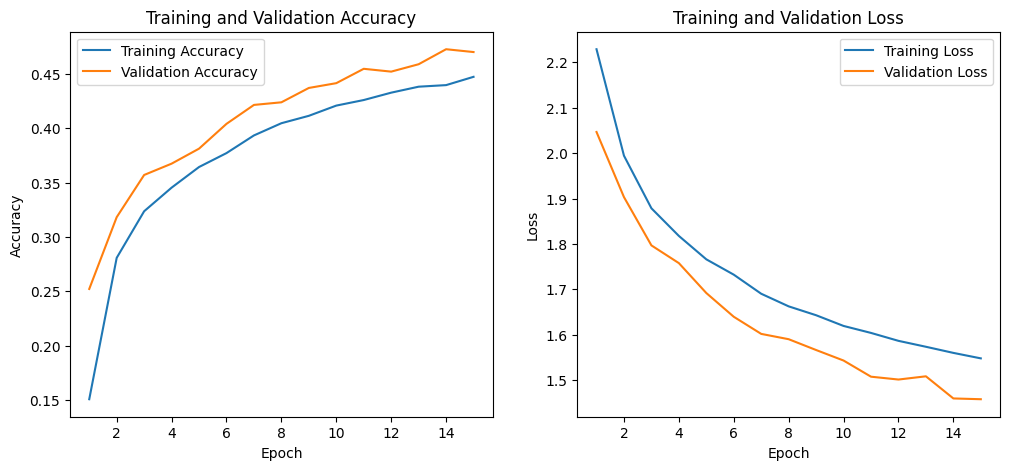

In [35]:
acc = history_aug.history['accuracy']
val_acc = history_aug.history['val_accuracy']

loss = history_aug.history['loss']
val_loss = history_aug.history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')

plt.show()

In [36]:
print("Original CNN Test Accuracy:", test_acc)
print("Augmented CNN Test Accuracy:", test_acc_aug)
print("Improvement:", (test_acc_aug - test_acc) * 100, "%")

Original CNN Test Accuracy: 0.45010000467300415
Augmented CNN Test Accuracy: 0.47999998927116394
Improvement: 2.989998459815979 %
